# Machine Learning Lab Evaluation

This lab includes two tasks: regression and classification. Each task compares three models: two traditional machine learning models and one neural network, with evaluations based on three metrics.

In [1]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
devices = tf.config.list_physical_devices('GPU')

if devices:
    for device in devices:
        details = tf.config.experimental.get_device_details(device)
        print(f"TensorFlow GPU:0 -> {details['device_name']}")
else:
    print("ไม่พบ GPU")

ไม่พบ GPU


## Task 1: Regression

### Step 1: Load Dataset
We use the Boston Housing dataset for the regression task.

Use Numpy library to import dataset.
<br>`numpy.load(FILE_PATH, allow_pickle=True).item()`
<br>The dataset structure is dictionary-format.

In [3]:
# Load the data

# -------------------------------
FILE_PATH = 'boston-dataset.npy'
df = np.load(FILE_PATH, allow_pickle=True).item()
df
# Your code here
# -------------------------------

{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
         4.9800e+00],
        [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
         9.1400e+00],
        [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
         4.0300e+00],
        ...,
        [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         5.6400e+00],
        [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
         6.4800e+00],
        [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         7.8800e+00]]),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 3

In [4]:
# Show 3 samples of dataset

# -------------------------------
print('Feature')
print(df['data'][:3])
print()
print('Target')
print(df['target'][:3])
# Your code here
# -------------------------------

Feature
[[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 3.9690e+02
  4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
  9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 7.1850e+00
  6.1100e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9283e+02
  4.0300e+00]]

Target
[24.  21.6 34.7]


### Step 2: Split and Scale Data
We split the dataset into training and testing sets, then standardize the features for better performance.

In [5]:
# Split the data using train_test_split function
# 80% of the data will be used for training and 20% for testing
X = df['data']
y = df['target']
# Random state is set to 42

# -------------------------------
# Your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
# -------------------------------

# Standardize the data
# Use StandardScaler to standardize the data
# Use fit_transform method on the training data and transform method on the testing data

# -------------------------------
# Your code here
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# -------------------------------

In [6]:
# Show variable shape

# -------------------------------
print("X_train > >",X_train.shape)
print("y_train > >",y_train.shape)
print("X_test > > ",X_test.shape)
print("y_test > > ",y_test.shape)
# Your code here
# -------------------------------

X_train > > (404, 13)
y_train > > (404,)
X_test > >  (102, 13)
y_test > >  (102,)


### Step 3: Train Models
We train three models: Linear Regression, Random Forest Regressor, and a Neural Network.
<br>Steps: 
1) Import/Build the model, 
2) Fit the model, 
3) Predict the target values.

In [7]:
# Linear Regression
# Create a Linear Regression model
# -------------------------------
# Your code here
model = LinearRegression()
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
model.fit(X_train, y_train)
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred = model.predict(X_test)
# -------------------------------

In [8]:
# Random Forest Regressor
# Use RandomForestRegressor to train the model with random_state=42
# -------------------------------
# Your code here
rf_model = RandomForestRegressor(random_state=42)
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
rf_model.fit(X_train, y_train)
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred_rf = rf_model.predict(X_test)
# -------------------------------

In [9]:
# Neural Network
# Create a neural network model with 2 hidden layers with 64 units and ReLU activation function

nn_model_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile the model with adam optimizer and mean squared error loss function
# -------------------------------
# Your code here
nn_model_reg.compile(optimizer='adam', loss='mse')
# -------------------------------

# Fit the model with 50 epochs and batch size of 16
# -------------------------------
# Your code here
nn_model_reg.fit(X_train, y_train, epochs=50, batch_size=16)
# -------------------------------

# Predict the target values using the model
# -------------------------------
# Your code here
y_pred_nn = nn_model_reg.predict(X_test)
# -------------------------------

Epoch 1/50


c:\Users\Nebula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 567.7957   
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 433.7851 
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 219.8145 
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 76.0683  
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41.5680 
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 30.3561 
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25.6678 
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.9358 
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.2999 
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 19.6095 
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.3443 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.5317 
Epoch 13/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.4744 
Epoch 14/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15.8287 
Epoch 15/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15.

### Step 4: Evaluate Models
We evaluate the models using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score.

In [10]:
# Evaluate the models

# -------------------------------
# Your code here
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mse_nn = mean_squared_error(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Regression Task:")
print("Linear Regression:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")
print()
print("Random Forest Regressor:")
print(f"MSE: {mse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")
print()
print("Neural Network:")
print(f"MSE: {mse_nn:.4f}")
print(f"MAE: {mae_nn:.4f}")
print(f"R2 Score: {r2_nn:.4f}")
# -------------------------------

Regression Task:
Linear Regression:
MSE: 24.2911
MAE: 3.1891
R2 Score: 0.6688

Random Forest Regressor:
MSE: 7.9127
MAE: 2.0411
R2 Score: 0.8921

Neural Network:
MSE: 11.4098
MAE: 2.2358
R2 Score: 0.8444


---
---
---

## Task 2: Classification

### Step 1: Load Dataset
We use the Iris dataset for the classification task.

In [11]:
# Load the data
# -------------------------------
# Your code here 
CSV_PATH = 'iris_dataset.csv'
df2 = pd.read_csv(CSV_PATH)
df2
print(df2.info()) # ดูประเภทข้อมูล
print(df2.describe()) # ดูสถิติเบื้องต้น
print(df2.isna().sum()) # นับจำนวนค่าว่าง (Missing Values) ในแต่ละคอลัมน์
df2["sepal_width"].fillna(df2["sepal_width"].mean(), inplace=True)
# -------------------------------

# Show the first 5 rows of the dataset
# -------------------------------
# Your code here
df2.head()
# -------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   target        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
       sepal_length  sepal_width  petal_length  petal_width      target
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    1.000000
std        0.828066     0.435866      1.765298     0.762238    0.819232
min        4.300000     2.000000      1.000000     0.100000    0.000000
25%        5.100000     2.800000      1.600000     0.300000    0.000000
50%        5.800000     3.000000      4.350000     1.300000    1.000000
75%        6.400000     3.300000    

C:\Users\Nebula\AppData\Local\Temp\ipykernel_49068\247823013.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["sepal_width"].fillna(df2["sepal_width"].mean(), inplace=True)


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


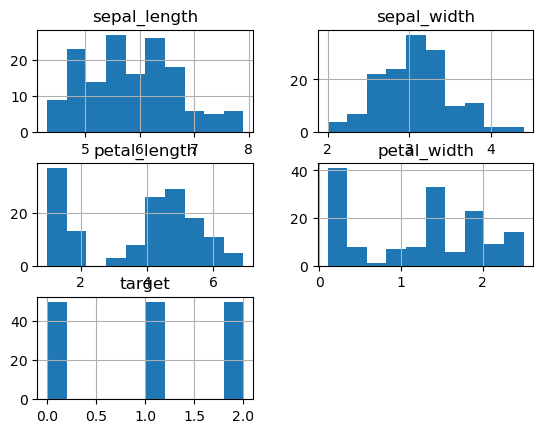

              sepal_length  sepal_width  petal_length  petal_width    target
sepal_length      1.000000    -0.117570      0.871754     0.817941  0.782561
sepal_width      -0.117570     1.000000     -0.428440    -0.366126 -0.426658
petal_length      0.871754    -0.428440      1.000000     0.962865  0.949035
petal_width       0.817941    -0.366126      0.962865     1.000000  0.956547
target            0.782561    -0.426658      0.949035     0.956547  1.000000


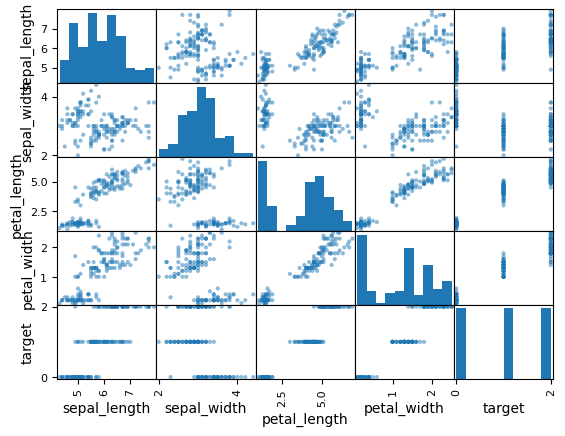

In [12]:
import matplotlib.pyplot as plt

# 1. ดูการกระจายตัวของข้อมูลแต่ละคอลัมน์
df2.hist()
plt.show()

# 2. ดูค่าสหสัมพันธ์ (Correlation Matrix) เพื่อหาตัวแปรที่ซ้ำซ้อน
print(df2.corr())

# 3. พล็อตกราฟ Scatter Matrix เพื่อดูความสัมพันธ์แบบคู่ (Pairwise)
pd.plotting.scatter_matrix(df2)
plt.show()

In [13]:
# Split the data into features and target
# -------------------------------
# Your code here
X = df2.drop('target', axis=1)
y = df2['target']
# -------------------------------

In [14]:
# Show 3 samples of features
# -------------------------------
# Your code here
print("Features")
print(X.values[:3])
print()
print("Target")
print(y.values[:3])
# -------------------------------

Features
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

Target
[0 0 0]


### Step 2: Split and Scale Data
We split the dataset into training and testing sets, then standardize the features for better performance.

In [15]:
# Split the data using train_test_split function
# 80% of the data will be used for training and 20% for testing
# Random state is set to 42
# -------------------------------
# Your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------

# Standardize the data
# Use StandardScaler to standardize the data
# Use fit_transform method on the training data and transform method on the testing data
# -------------------------------
# Your code here
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# -------------------------------

### Step 2.5: Encode Target Variable
We encode the target variable using One-Hot Encoding.

In [16]:
# One-hot encode for neural network
# -------------------------------
# Your code here
y_train = to_categorical(y_train)
y_test = to_categorical(y_test, num_classes=3)
# -------------------------------

In [17]:
# Show variable shape
# -------------------------------
# Your code here
print("Variable shape")
print("X_train >> ", X_train.shape)
print("y_train >> ", y_train.shape)
print("X_test >> ", X_test.shape)
print("y_test >> ", y_test.shape)
# -------------------------------

Variable shape
X_train >>  (120, 4)
y_train >>  (120, 3)
X_test >>  (30, 4)
y_test >>  (30, 3)


### Step 3: Train Models
We train three models: Logistic Regression, Random Forest Classifier, and a Neural Network.
<br>Steps: 
1) Import/Build the model, 
2) Fit the model, 
3) Predict the target values.

In [18]:
# Logistic Regression
# Create a Logistic Regression model
# -------------------------------
# Your code here
lr_model = LogisticRegression()
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
lr_model.fit(X_train, np.argmax(y_train, axis=1))
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred_lr = lr_model.predict(X_test)
# -------------------------------

In [19]:
# Random Forest Classifier
# Use RandomForestClassifier to train the model with random_state=42
# -------------------------------
# Your code here
rf_model_clf = RandomForestClassifier(random_state=42)
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
rf_model_clf.fit(X_train, y_train)
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred_rf_clf = rf_model_clf.predict(X_test)
# -------------------------------

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# สมมติว่าสร้างโมเดล Random Forest ไว้แล้ว (rf_model_clf = RandomForestClassifier(...))
# 1. สร้างตัวแบ่งกลุ่มข้อมูลแบบ 5-Folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. ทำการประเมินแบบ Cross-Validation ใน Training set
scores = cross_val_score(rf_model_clf, X_train, np.argmax(y_train, axis=1), cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {scores}")
print(f"Mean CV Accuracy: {scores.mean():.4f}")

Cross-Validation Accuracy Scores: [0.95833333 0.95833333 0.875      0.95833333 0.91666667]
Mean CV Accuracy: 0.9333


In [21]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# สร้างและ Train โมเดลเพิ่มเติม
svc_model = SVC(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

svc_model.fit(X_train, np.argmax(y_train, axis=1))
knn_model.fit(X_train, np.argmax(y_train, axis=1))
dt_model.fit(X_train, np.argmax(y_train, axis=1))

DecisionTreeClassifier(max_depth=3, random_state=42)

Epoch 1/50


c:\Users\Nebula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3083 - loss: 1.1710 - val_accuracy: 0.4000 - val_loss: 1.0278
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5000 - loss: 0.9914 - val_accuracy: 0.9000 - val_loss: 0.8696
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7083 - loss: 0.8618 - val_accuracy: 0.9000 - val_loss: 0.7364
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7333 - loss: 0.7367 - val_accuracy: 0.8667 - val_loss: 0.6205
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.6750 - val_accuracy: 0.9000 - val_loss: 0.5255
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7833 - loss: 0.5600 - val_accuracy: 0.9000 - val_loss: 0.4529
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8083 - loss: 0.5109 - val_accuracy: 0.9000 - val_loss: 0.3967
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8167 - loss: 0.4773 - val_accuracy: 0.9000 - val_loss: 0.3561
Epoch 9/50
8/8 ━━━

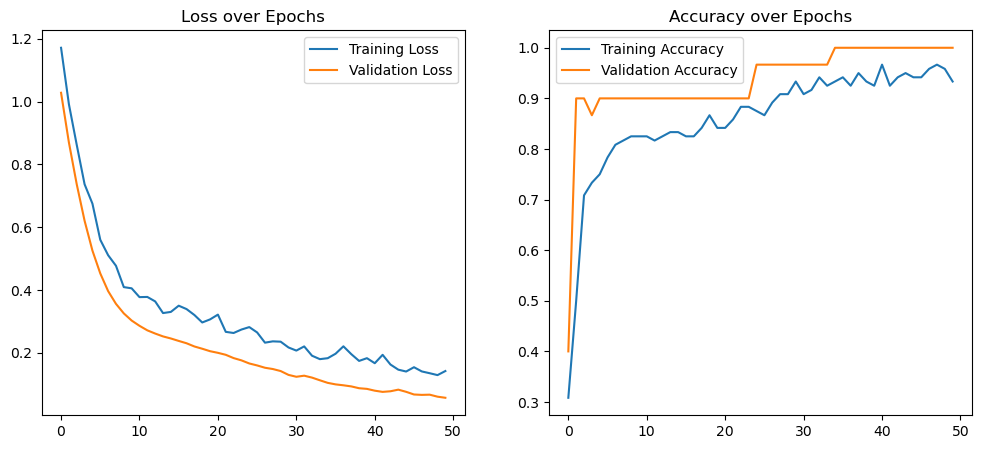

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [22]:
# Neural Network
# Create a neural network model with 2 hidden layers with 64 units and ReLU activation function
from tensorflow.keras.layers import Dense, Dropout

# โครงสร้างอ้างอิงตาม Lab 8 คือมี 2 Hidden layers (ชั้นละ 64)
nn_model_cls = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # ใช้ [1] เหมือนเดิม
    Dropout(0.3), # <--- แทรก Dropout เพื่อป้องกันโมเดลจำข้อสอบ (Overfitting)
    
    Dense(64, activation='relu'), # ชั้นซ่อน (Hidden Layer) ที่ 2
    Dropout(0.3), # <--- ใส่เพิ่มอีกชั้นได้เพื่อประสิทธิภาพที่ดีขึ้น
    
    Dense(y_train.shape[1], activation='softmax') # ใช้ [1] เหมือนเดิม
])

# Compile the model with adam optimizer and categorical crossentropy loss function
# Use accuracy as the metric
# -------------------------------
# Your code here
nn_model_cls.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# -------------------------------

# Fit the model with 50 epochs and batch size of 16
# -------------------------------
# Your code here
# 1. ให้เพิ่มตัวแปร history มารับค่าการ fit
history = nn_model_cls.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# 2. พล็อตกราฟ Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

# 3. พล็อตกราฟ Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()
# -------------------------------

# Predict the target values using the model
# Use argmax to get the predicted class
# -------------------------------
# Your code here
y_pred_nn = nn_model_cls.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn, axis=1)
# -------------------------------

### Step 4: Evaluate Models
We evaluate the models using Accuracy, Precision, and Recall.

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
# Evaluate the models
# -------------------------------
# Your code here
y_test_1d = np.argmax(y_test, axis=1)
y_pred_rf_1d = np.argmax(y_pred_rf_clf, axis=1)

print("Classification Task:")
print("Logistic Regression:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_lr):.4f}")
print("Precision:", f"{precision_score(y_test_1d, y_pred_lr, average='weighted'):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_lr, average='weighted'):.4f}")
print("F1 Score:", f"{f1_score(y_test_1d, y_pred_lr, average='weighted'):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_lr))
print()
print("Random Forest Classifier:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_rf_1d):.4f}")
print("Precision:", f"{precision_score(y_test_1d, y_pred_rf_1d, average='weighted'):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_rf_1d, average='weighted'):.4f}")
print("F1 Score:", f"{f1_score(y_test_1d, y_pred_rf_1d, average='weighted'):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_rf_1d))
print()
print("Neural Network:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_nn):.4f}")
print("Precision:", f"{precision_score(y_test_1d, y_pred_nn, average='weighted'):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_nn, average='weighted'):.4f}")
print("F1 Score:", f"{f1_score(y_test_1d, y_pred_nn, average='weighted'):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_nn))

# -------------------------------

Classification Task:
Logistic Regression:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Random Forest Classifier:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Neural Network:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [24]:
y_pred_svc = svc_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# (แปลง y_test กลับเป็นมิติเดียว หากในโค้ดยังไม่มีตัวแปรนี้)
# y_test_1d = np.argmax(y_test, axis=1) 

# 2. ขั้นตอน Evaluate: แสดงผลลัพธ์ด้วย Confusion Matrix และ Classification Report
print("=== Support Vector Classifier (SVC) Report ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_svc))
print("Report:")
print(classification_report(y_test_1d, y_pred_svc, digits=4))
print("-" * 50)

print("=== k-Nearest Neighbors (k-NN) Report ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_knn))
print("Report:")
print(classification_report(y_test_1d, y_pred_knn, digits=4))
print("-" * 50)

print("=== Decision Tree Report ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_dt))
print("Report:")
print(classification_report(y_test_1d, y_pred_dt, digits=4))
print("-" * 50)

=== Support Vector Classifier (SVC) Report ===
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000         9
           2     1.0000    1.0000    1.0000        11

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30

--------------------------------------------------
=== k-Nearest Neighbors (k-NN) Report ===
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000         9
           2     1.0000    1.0000    1.0000        11

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    